# Variational Autoencoder

![VAE](notebook_images/vae.jpg)

Variational Autoencoder (VAE) extends the vanilla autoencoder by introducing a probabilistic latent space. For each input, the encoder outputs the parameters (mean $\mu$ and standard deviation $\sigma$) of a normal distribution $N(\mu, \sigma)$, from which the latent vector $Z$ is sampled. This regularizes the latent space and typically improves generative performance. However, in terms of reconstruction quality, VAEs are not necessarily better than standard autoencoders.

**Original paper:**

Diederik P Kingma, Max Welling - Auto-Encoding Variational Bayes - https://arxiv.org/abs/1312.6114

## $\beta$ VAE

The β-VAE paper introduces a hyperparameter, β, to the loss function, which scales the weight of the KL divergence term relative to the reconstruction loss. This modification enables explicit control over the trade-off between reconstruction fidelity and the disentanglement of the latent space. 

**Paper**

Irina Higgins, Loic Matthey, Arka Pal, Christopher Burgess, Xavier Glorot, Matthew Botvinick, Shakir Mohamed, Alexander Lerchner -  beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework - https://openreview.net/forum?id=Sy2fzU9gl

**Further reading:**

Understanding Variational Autoencoders (VAEs) - https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73



In [ ]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

In [2]:
print(torch.__version__)

2.2.1+cu118


## Aux functions for display purposes

In [3]:
from matplotlib import colors

def plot_scatter(x,y,targets):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(12,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = 1, norm=norm)
    plt.colorbar()

    plt.show()


def show_preds(set1, set2, count):
  
  columns = 4
  rows = int(count*2 / columns) + 1  
  plt.figure(figsize=(count, 2 * rows))
  
  for n in range(count):
      ax = plt.subplot(rows, columns, n*2+1)
      plt.title("original")
      plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')
      ax = plt.subplot(rows, columns, n*2+2)
      plt.title("reconstruction")
      plt.imshow(np.transpose(set2[n].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')      

## Configuration

In [4]:
HEIGHT = 28
WIDTH = 28
NUM_CHANNELS = 1
BATCH_SIZE = 128
LATENT_SPACE_DIM = 2

MODEL_PATH = 'vae_models'

TRAIN_ONLINE = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


### Load and prepare MNIST dataset

In [5]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

train_set = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                          shuffle=True)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

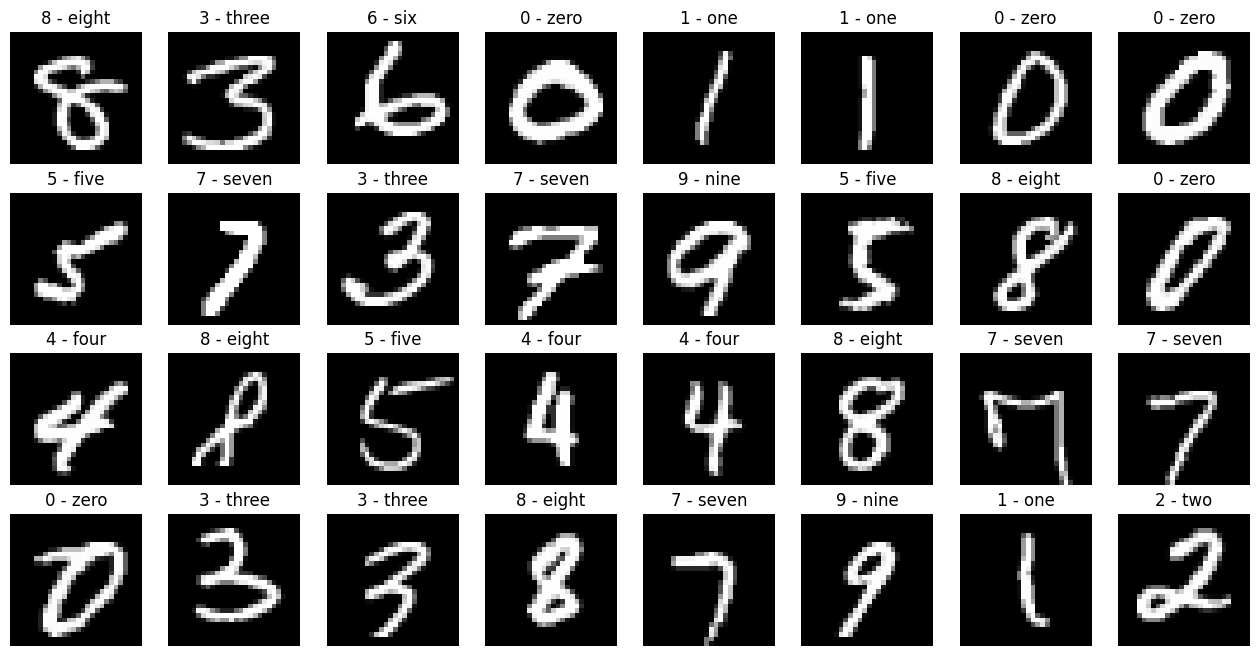

<Figure size 640x480 with 0 Axes>

In [6]:
images, targets = next(iter(train_loader))

vcpi_util.show_images(4,8, images, targets, train_set.classes) 

## Architecture

We are modelling a class for the encoder, and another for the decoder. These two classes will be the main building blocks of the autoencoder class, together with the sampling procedure.

In [7]:
class Encoder(torch.nn.Module):

    def __init__(self, latent_space_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size= 3, 
                                      stride = 2, padding = 1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size= 3, 
                                      stride = 2, padding = 1),
            torch.nn.ReLU(),
            nn.BatchNorm2d(64),
        )

        self.efc1_mean = torch.nn.Linear(3136, latent_space_dim)
        self.efc1_log_var = torch.nn.Linear(3136, latent_space_dim)

    def forward(self, x):

        x = self.encoder(x)

        x = torch.flatten(x,1)
        mean = self.efc1_mean(x)
        log_var = self.efc1_log_var(x)

        return mean, log_var


In [8]:
class Decoder(torch.nn.Module):

    def __init__(self, latent_space_dim):
        
        super().__init__()

        self.dfc1 = torch.nn.Linear(latent_space_dim, 3136)
        
        self.dconvT1 = torch.nn.ConvTranspose2d(64, 32, 3, 2, padding = 1, output_padding=1)
        self.drelu1 = torch.nn.ReLU()
        self.dbn1 = torch.nn.BatchNorm2d(32)

        self.dconvT2 = torch.nn.ConvTranspose2d(32, 1,3,2, padding = 1, output_padding = 1)
        self.dsig = torch.nn.Sigmoid()


    def forward(self, x):

        x = self.dfc1(x)
        x = x.reshape(-1, 64, 7, 7)
        x = self.dconvT1(x)
        x = self.dbn1(x)
        x = self.drelu1(x)

        x = self.dconvT2(x)
        x = self.dsig(x)

        return x        

### Sampling Layer

The output of the encoder is $\hspace{0.5cm}$ $\mu$ (mean), $\log(\sigma^2)$ (log-variance)

Note:
Log-variance can assume any value, whereas variances are by definition positive. Since the outupt of a unit is not necessarily unbounded, the usage of log-variance ensures that variance, obtained after exponentiation, is positive.




Consider: $\hspace{0.5cm}$ $\epsilon  \thicksim N(0,1)$

Sampling from a normal distribution $N(\mu, \sigma^2)$: 

$$z = \mu + \sigma \times \epsilon$$

However, we don't have $\sigma$, we have $\log(\sigma^2)$, hence:

$$
\begin{align*}
z &= \mu + \sigma \cdot \epsilon \\
  &= \mu + \exp(\log(\sigma)) \cdot \epsilon \\
  &= \mu + \exp\left(0.5 \cdot (\log(\sigma) + \log(\sigma))\right) \cdot \epsilon \\
  &= \mu + \exp\left(0.5 \cdot \log(\sigma^2)\right) \cdot \epsilon
\end{align*}
$$

$z$ will then be the input of the decoder.


In [9]:
class VAE(torch.nn.Module):

    def __init__(self, encoder, decoder):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def reparametrization(self, mean, var):

        epsilon = torch.randn_like(mean).to(device)    
        z = mean + var * epsilon  
        return z  

    def forward(self, x):

        mean, log_var = self.encoder(x)
        var = torch.exp(0.5 * log_var)
        z = self.reparametrization(mean, var)
        output = self.decoder(z)

        return output, mean, log_var

In [10]:
encoder = Encoder(LATENT_SPACE_DIM)
decoder = Decoder(LATENT_SPACE_DIM)

model = VAE(encoder=encoder, decoder=decoder).to(device)
model.to(device)

torchinfo.summary(model, input_size=(BATCH_SIZE, 1, 28, 28), col_names=["kernel_size", "input_size", "output_size", "num_params", "mult_adds"])



Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape              Param #                   Mult-Adds
VAE                                      --                        [128, 1, 28, 28]          [128, 1, 28, 28]          --                        --
├─Encoder: 1-1                           --                        [128, 1, 28, 28]          [128, 2]                  --                        --
│    └─Sequential: 2-1                   --                        [128, 1, 28, 28]          [128, 64, 7, 7]           --                        --
│    │    └─Conv2d: 3-1                  [3, 3]                    [128, 1, 28, 28]          [128, 32, 14, 14]         320                       8,028,160
│    │    └─ReLU: 3-2                    --                        [128, 32, 14, 14]         [128, 32, 14, 14]         --                        --
│    │    └─BatchNorm2d: 3-3             --                        [128, 32, 14, 14]         [128,

## Loss function

The Variational Autoencoder (VAE) loss function has two components: 

- **Reconstruction loss** - this term is similar to the loss used in a regular autoencoder. It measures the discrepancy between the obtained output and the desired output, and its purpose is to encourage faithful reconstruction of the input data


<div align="center">

 $\text{Reconstruction loss} = 1/N \sum (train_x - output)^2$ 
</div>

- **KL loss**: this term is the Kullback-Leibler (KL) divergence between the learned distribution  and a known prior distribution (typically a standard normal distribution). The goal is to obtain a distribution as close as possible to the prior distribution, thereby ensuring that the latent space can be easily explored. For the KL Loss we are considering the prior to be a Normal distribution with $\mu = 0$ and $\sigma = 1$

<div align="center">

$\text{KL loss} = -0.5 \times \sum  (1 + log(\sigma^2) - \mu^2 - e^{log(\sigma^2)})$</p>
</div>

Total VAE Loss:
<div align="center">

$\text{Total Loss = Reconstruction loss + KL loss}$</p>
</div>

In $\beta$-VAE the loss function is:
<div align="center">

$\text{Total Loss = Reconstruction loss} + \beta \times \text{KL loss}$</p>
</div>

Setting β greater than 1, β-VAE encourages the model to learn more independent and interpretable latent factors, leading to representations where individual latent variables correspond to distinct generative factors in the data. 



In [11]:
BCE_loss = torch.nn.BCELoss(reduction = 'sum')

def loss_function(x, output, mean, log_var):
    reproduction_loss = BCE_loss(output, x)
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + 1.1 *  KLD, reproduction_loss, KLD


optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

## Training

In [12]:
if TRAIN_ONLINE:

    EPOCHS = 10

    print("Start training VAE...")
    model.train()

    best_loss = float('inf')

    for epoch in range(EPOCHS):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):

            x = x.to(device)

            optimizer.zero_grad()

            output, mean, log_var = model(x)
            loss, Rloss, KLloss = loss_function(x, output, mean, log_var)
            
            overall_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            
        print("\tEpoch", epoch + 1, "complete!", "\tTotal Loss: ", loss.item() / (batch_idx*BATCH_SIZE), "\tReconstruction Loss: ", Rloss.item() / (batch_idx*BATCH_SIZE), "\tKL Loss: ", KLloss.item() / (batch_idx*BATCH_SIZE))
        
        if loss < best_loss:
            best_loss = loss
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'optimizer': optimizer.state_dict()
                },
                f'{MODEL_PATH}/vae_{LATENT_SPACE_DIM}_best.pt')
            
    print("Finish!!")

    model.eval()

Start training VAE...
	Epoch 1 complete! 	Total Loss:  0.28985559838449854 	Reconstruction Loss:  0.28253173828125 	KL Loss:  0.006658068579486293
	Epoch 2 complete! 	Total Loss:  0.2684951521392561 	Reconstruction Loss:  0.2605818887042184 	KL Loss:  0.007193872561821571
	Epoch 3 complete! 	Total Loss:  0.2584881578755175 	Reconstruction Loss:  0.2500159434783153 	KL Loss:  0.007702008271828676
	Epoch 4 complete! 	Total Loss:  0.25664859347873265 	Reconstruction Loss:  0.24812698364257812 	KL Loss:  0.007746920626387637
	Epoch 5 complete! 	Total Loss:  0.26883911067604 	Reconstruction Loss:  0.2610127701718583 	KL Loss:  0.0071148566710643275
	Epoch 6 complete! 	Total Loss:  0.26360621004023105 	Reconstruction Loss:  0.25521813091049844 	KL Loss:  0.0076255263426364996
	Epoch 7 complete! 	Total Loss:  0.2678743346124633 	Reconstruction Loss:  0.25923208905081463 	KL Loss:  0.00785658604059464
	Epoch 8 complete! 	Total Loss:  0.268583982418745 	Reconstruction Loss:  0.2599178216396234 

In [15]:
reload = torch.load(f'{MODEL_PATH}/vae_{LATENT_SPACE_DIM}_best.pt')
print(reload['epoch'])
model = VAE(Encoder(LATENT_SPACE_DIM), Decoder(LATENT_SPACE_DIM))
model.to(device)
model.load_state_dict(reload['model'])

9


<All keys matched successfully>

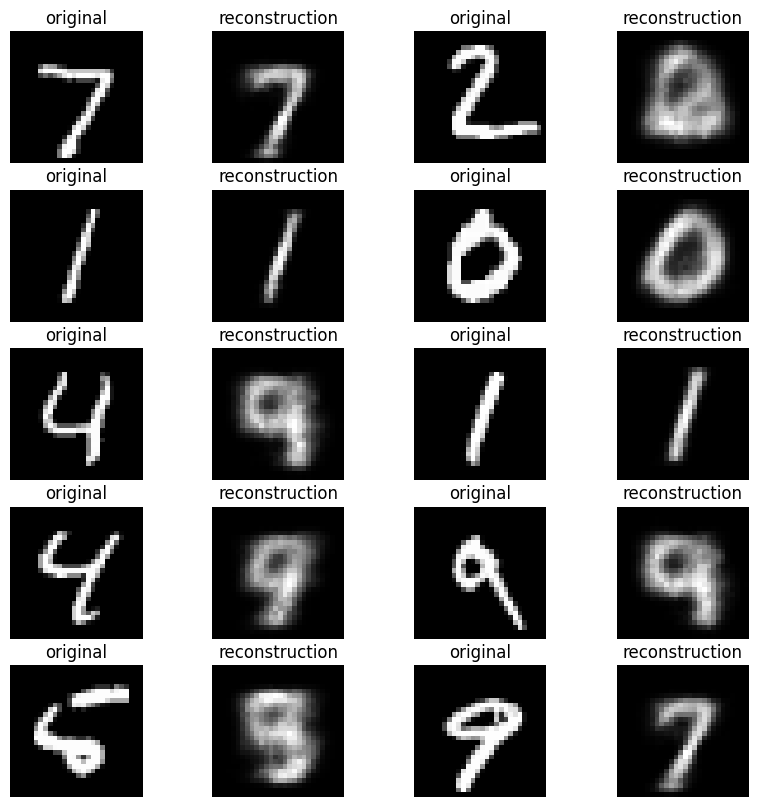

In [16]:
i, _ = next(iter(test_loader))
recon,_,_ = model(i.to(device))
    
show_preds(i, recon, 10)

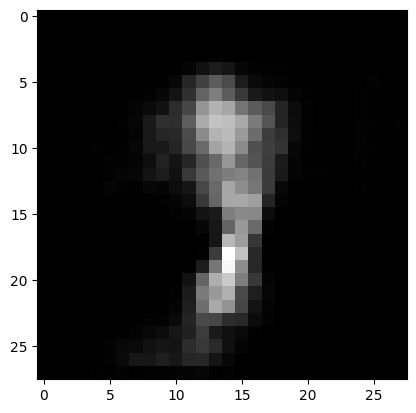

In [17]:
pred = model.decoder(torch.randn(LATENT_SPACE_DIM).to(device))
plt.imshow(np.transpose(pred[0].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)

Displaying Latent Space

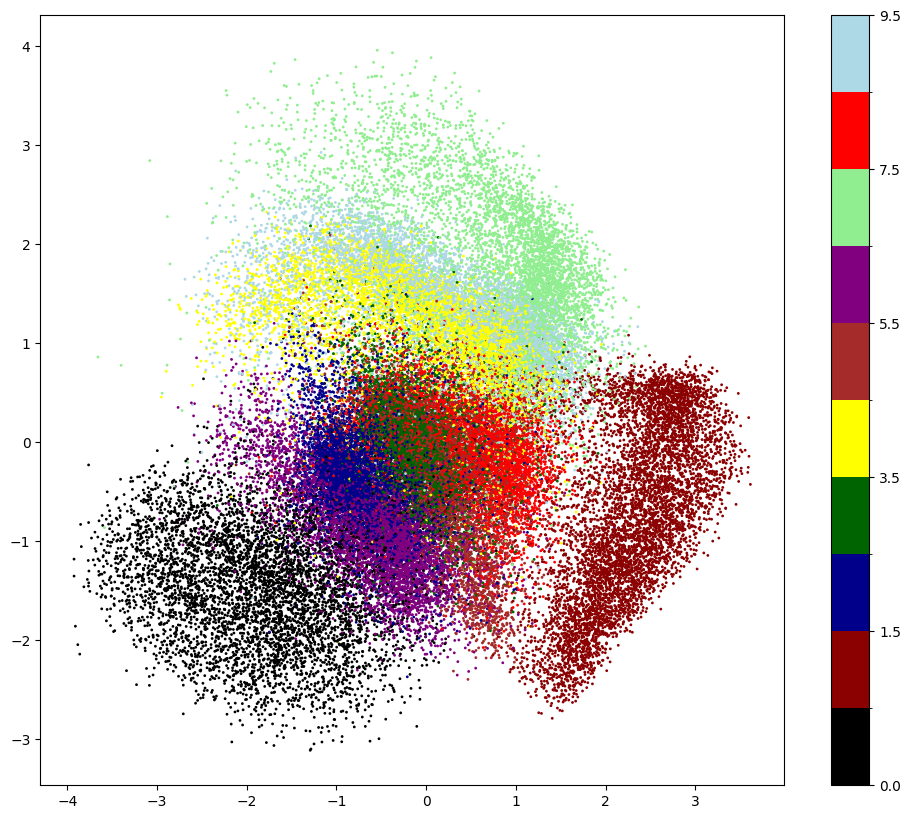

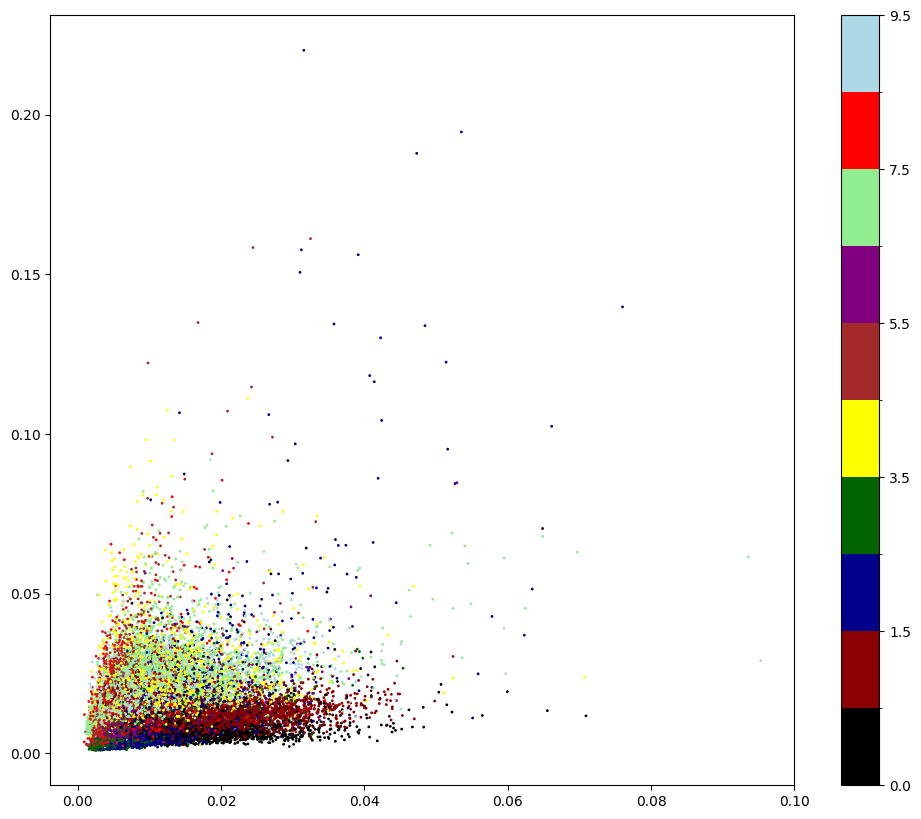

In [18]:
import math

if LATENT_SPACE_DIM == 2:

    encoded_mean = []
    encoded_log_var = []
    targets = []
    for i,t in train_loader:
        mean, log_var = model.encoder(i.to(device))
        encoded_mean.extend(mean.cpu().detach().numpy())  
        encoded_log_var.extend(log_var.cpu().detach().numpy())
        targets.extend(t)

    x = [m[0] for m in encoded_mean]
    y = [m[1] for m in encoded_mean]

    plot_scatter(x,y,targets)

    x = [math.exp(m[0]) for m in encoded_log_var]
    y = [math.exp(m[1]) for m in encoded_log_var]

    plot_scatter(x,y,targets)

## Sampling Interval Based on the Empirical Rule

The **empirical rule** (also known as the 68-95-99.7 rule) describes how data is distributed in a normal distribution:

- Approximately **68%** of values lie within **one standard deviation** of the mean.
- Approximately **95%** lie within **two standard deviations**.
- Approximately **99.7%** lie within **three standard deviations**.



Intervals for a Standard Normal Distribution ($\mathcal{N}(0, 1)$)

| Coverage | Interval    |
|----------|-------------|
| 68%      | [-1, 1]     |
| 95%      | [-2, 2]     |
| 99.7%    | [-3, 3]     |

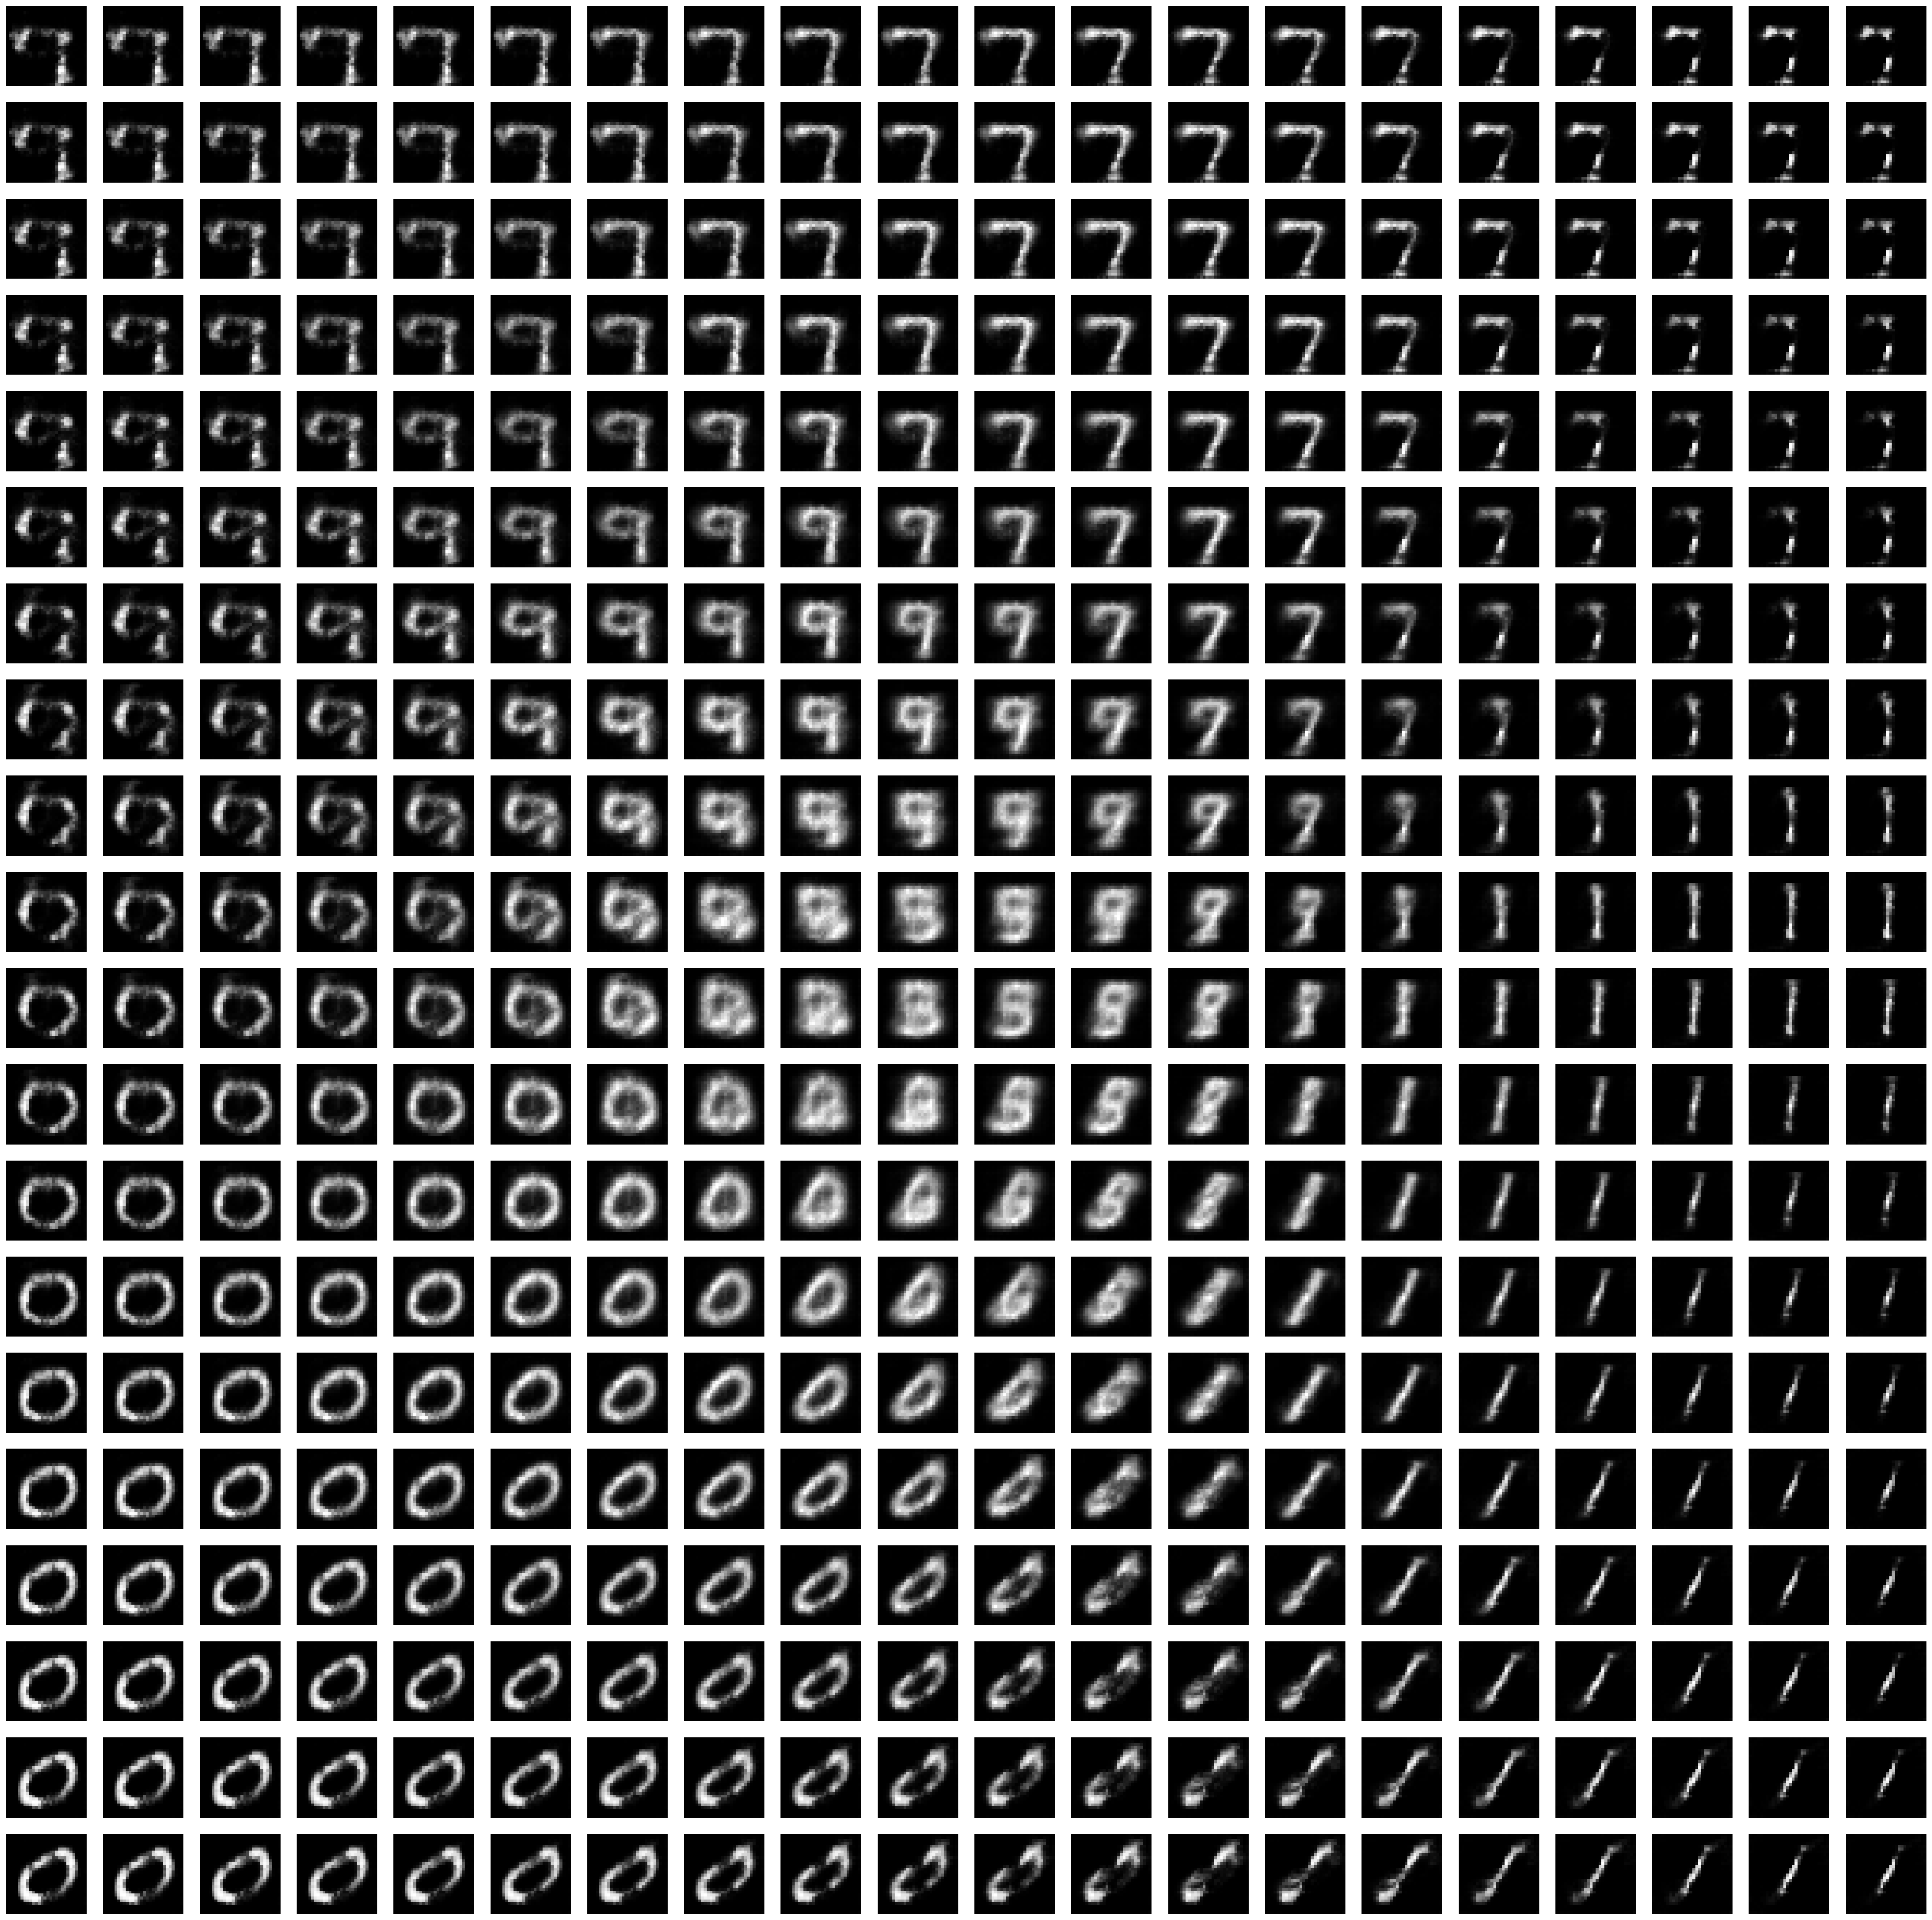

<Figure size 640x480 with 0 Axes>

In [19]:
if LATENT_SPACE_DIM == 2:
    limit = 5
    steps = 20

    step = (2.0 * limit) / steps

    vector_generation = [[-limit + j*step, limit - i*step] 
                                for i in range(steps) for j in range(steps)]

    predictions = model.decoder(torch.Tensor(vector_generation).to(device))

    vcpi_util.show_predicted_images(steps, steps, predictions.cpu().detach(), 10)